In [35]:
# Block 1.1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split

# Regression
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Classification
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix)
import lightgbm as lgb

# Recommendation
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

# Save
import joblib

pd.set_option('display.max_columns', None)
print("Libraries imported.")

Libraries imported.


In [2]:
# Block 1.2: Load All Datasets
transaction_df = pd.read_csv('Tourism Dataset/Transaction.csv')
item_df = pd.read_csv('Tourism Dataset/Item.csv')
city_df = pd.read_csv('Tourism Dataset/City.csv')
country_df = pd.read_csv('Tourism Dataset/Country.csv')
region_df = pd.read_csv('Tourism Dataset/Region.csv')
continent_df = pd.read_csv('Tourism Dataset/Continent.csv')
mode_df = pd.read_csv('Tourism Dataset/Mode.csv')

print("Shapes:")
print("Transaction:", transaction_df.shape)
print("Item:", item_df.shape)
print("City:", city_df.shape)
print("Country:", country_df.shape)
print("Region:", region_df.shape)
print("Continent:", continent_df.shape)
print("Mode:", mode_df.shape)

Shapes:
Transaction: (52930, 7)
Item: (30, 5)
City: (9143, 3)
Country: (165, 3)
Region: (22, 3)
Continent: (6, 2)
Mode: (6, 2)


In [3]:
# Block 1.3: Preview Data
display(transaction_df.head())
display(item_df.head())
display(city_df.head())
display(mode_df.head())

,TransactionId,UserId,VisitYear,VisitMonth,VisitMode,AttractionId,Rating
0,3,70456,2022,10,2,640,5
1,8,7567,2022,10,4,640,5
2,9,79069,2022,10,3,640,5
3,10,31019,2022,10,3,640,3
4,15,43611,2022,10,2,640,3


,AttractionId,AttractionCityId,AttractionTypeId,Attraction,AttractionAddress
0,369,1,13,Kuta Beach - Bali,Kuta
1,481,1,13,Nusa Dua Beach,"Semenanjung Nusa Dua, Nusa Dua 80517 Indonesia"
2,640,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia"
3,650,1,13,Sanur Beach,Sanur
4,673,1,13,Seminyak Beach,Seminyak


,CityId,CityName,CountryId
0,0,-,0
1,1,Douala,1
2,2,South Region,1
3,3,N'Djamena,2
4,4,Kigali,3


,VisitModeId,VisitMode
0,0,-
1,1,Business
2,2,Couples
3,3,Family
4,4,Friends


# PHASE 2: Data Cleaning


In [4]:
# Block 2.1: Check Missing Values
print("Missing Values:")
for name, df in [('Transaction', transaction_df), ('Item', item_df),
                 ('City', city_df), ('Mode', mode_df)]:
    print(f"\n{name}:")
    print(df.isnull().sum())

Missing Values:

Transaction:
TransactionId    0
UserId           0
VisitYear        0
VisitMonth       0
VisitMode        0
AttractionId     0
Rating           0
dtype: int64

Item:
AttractionId         0
AttractionCityId     0
AttractionTypeId     0
Attraction           0
AttractionAddress    0
dtype: int64

City:
CityId       0
CityName     1
CountryId    0
dtype: int64

Mode:
VisitModeId    0
VisitMode      0
dtype: int64


In [5]:
# Block 2.2: Check for Invalid Ratings & Duplicates
print("Rating range:", transaction_df['Rating'].min(), "-", transaction_df['Rating'].max())
print("Invalid ratings:", len(transaction_df[(transaction_df['Rating'] < 1) | (transaction_df['Rating'] > 5)]))
print("Duplicates in Transaction:", transaction_df.duplicated().sum())
print("Duplicates in Item:", item_df.duplicated().sum())

Rating range: 1 - 5
Invalid ratings: 0
Duplicates in Transaction: 0
Duplicates in Item: 0


In [6]:
# Block 2.3: Clean Transaction Data
transaction_df = transaction_df[(transaction_df['Rating'] >= 1) & (transaction_df['Rating'] <= 5)]
transaction_df = transaction_df.drop_duplicates()
transaction_df['AttractionId'] = transaction_df['AttractionId'].astype(int)
transaction_df['UserId'] = transaction_df['UserId'].astype(int)
transaction_df['VisitMode'] = transaction_df['VisitMode'].astype(int)
transaction_df['VisitYear'] = transaction_df['VisitYear'].astype(int)
transaction_df['VisitMonth'] = transaction_df['VisitMonth'].astype(int)

print("Cleaned Transaction shape:", transaction_df.shape)

Cleaned Transaction shape: (52930, 7)


In [7]:
# Block 2.4: Clean Item Data
item_df['Attraction'] = item_df['Attraction'].fillna('Unknown')
item_df['AttractionAddress'] = item_df['AttractionAddress'].fillna('Unknown')
item_df['AttractionId'] = item_df['AttractionId'].astype(int)
item_df['AttractionCityId'] = item_df['AttractionCityId'].astype(int)
item_df['AttractionTypeId'] = item_df['AttractionTypeId'].astype(int)
item_df = item_df.drop_duplicates()

print("Cleaned Item shape:", item_df.shape)

Cleaned Item shape: (30, 5)


In [8]:
# Block 2.5: Standardize City & Mode
city_df['CityName'] = city_df['CityName'].str.strip()
mode_df['VisitMode'] = mode_df['VisitMode'].str.strip()

visit_mode_map = dict(zip(mode_df['VisitModeId'].astype(int), mode_df['VisitMode']))
print("Visit Mode Map:", visit_mode_map)

Visit Mode Map: {0: '-', 1: 'Business', 2: 'Couples', 3: 'Family', 4: 'Friends', 5: 'Solo'}


# PHASE 3: Preprocessing & Feature Engineering


In [9]:
# Block 3.1: Attraction Type Mapping
attraction_type_map = {
    2: 'Temple', 10: 'Cultural Show', 13: 'Beach', 19: 'Cave',
    34: 'Street/Area', 44: 'Palace', 45: 'Museum', 61: 'National Park',
    63: 'Wildlife', 64: 'Village', 72: 'Landmark', 76: 'Temple',
    82: 'Wellness', 84: 'Museum', 91: 'Volcano', 92: 'Water Park', 93: 'Waterfall'
}
item_df['AttractionType'] = item_df['AttractionTypeId'].map(attraction_type_map).fillna('Other')
print(item_df['AttractionType'].value_counts())

AttractionType
Beach            6
Temple           4
Landmark         3
Wildlife         2
Waterfall        2
National Park    2
Volcano          2
Museum           2
Water Park       1
Village          1
Wellness         1
Cave             1
Street/Area      1
Cultural Show    1
Palace           1
Name: count, dtype: int64


In [10]:
# Block 3.2: Merge All Data into Master Dataset
master_df = transaction_df.copy()
master_df = master_df.merge(
    item_df[['AttractionId', 'AttractionCityId', 'AttractionTypeId', 'Attraction',
             'AttractionAddress', 'AttractionType']],
    on='AttractionId', how='left'
)
master_df = master_df.merge(
    city_df[['CityId', 'CityName']].rename(columns={'CityId': 'AttractionCityId'}),
    on='AttractionCityId', how='left'
)
master_df['VisitModeName'] = master_df['VisitMode'].map(visit_mode_map)
master_df['Attraction'] = master_df['Attraction'].fillna('Unknown')
master_df['CityName'] = master_df['CityName'].fillna('Unknown')

print("Master shape:", master_df.shape)
display(master_df.head())

Master shape: (52930, 14)


,TransactionId,UserId,VisitYear,VisitMonth,VisitMode,AttractionId,Rating,AttractionCityId,AttractionTypeId,Attraction,AttractionAddress,AttractionType,CityName,VisitModeName
0,3,70456,2022,10,2,640,5,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Wildlife,Douala,Couples
1,8,7567,2022,10,4,640,5,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Wildlife,Douala,Friends
2,9,79069,2022,10,3,640,5,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Wildlife,Douala,Family
3,10,31019,2022,10,3,640,3,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Wildlife,Douala,Family
4,15,43611,2022,10,2,640,3,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Wildlife,Douala,Couples


In [11]:
# Block 3.3: Feature Engineering - Season & Quarter
master_df['Season'] = master_df['VisitMonth'].apply(
    lambda x: 'Winter' if x in [12,1,2] else 'Spring' if x in [3,4,5]
    else 'Summer' if x in [6,7,8] else 'Fall'
)
master_df['Quarter'] = master_df['VisitMonth'].apply(lambda x: (x-1)//3 + 1)

In [12]:
# Block 3.4: User-Level Features
user_features = master_df.groupby('UserId').agg(
    UserAvgRating=('Rating', 'mean'),
    UserVisitCount=('TransactionId', 'count'),
    UserUniqueAttractions=('AttractionId', 'nunique'),
    UserPreferredMode=('VisitModeName', lambda x: x.mode().iloc[0] if len(x.mode())>0 else 'Unknown'),
    UserPreferredType=('AttractionType', lambda x: x.mode().iloc[0] if len(x.mode())>0 else 'Unknown')
).reset_index()
print(user_features.head())

   UserId  UserAvgRating  UserVisitCount  UserUniqueAttractions  \
0      14       4.666667               3                      2   
1      16       4.700000              10                      5   
2      20       4.000000               1                      1   
3      23       5.000000               1                      1   
4      25       5.000000               1                      1   

  UserPreferredMode UserPreferredType  
0           Friends          Landmark  
1            Family          Wildlife  
2            Family        Water Park  
3           Friends          Landmark  
4           Friends     National Park  


In [13]:
# Block 3.5: Attraction-Level Features
attraction_features = master_df.groupby('AttractionId').agg(
    AttractionAvgRating=('Rating', 'mean'),
    AttractionTotalVisits=('TransactionId', 'count')
).reset_index()
print(attraction_features.head())

   AttractionId  AttractionAvgRating  AttractionTotalVisits
0           369             3.415190                   2765
1           481             4.275665                   2104
2           640             4.267086                  13198
3           650             3.976347                   3044
4           673             3.800618                   2914


In [14]:
# Block 3.6: Merge Features Back
master_df = master_df.merge(user_features, on='UserId', how='left')
master_df = master_df.merge(attraction_features, on='AttractionId', how='left')
print("Final Master shape:", master_df.shape)

Final Master shape: (52930, 23)


In [15]:
# Block 3.7: Encode Categorical Variables
le_type = LabelEncoder()
le_mode = LabelEncoder()
le_season = LabelEncoder()

master_df['AttractionType_enc'] = le_type.fit_transform(master_df['AttractionType'])
master_df['VisitModeName_enc'] = le_mode.fit_transform(master_df['VisitModeName'])
master_df['Season_enc'] = le_season.fit_transform(master_df['Season'])

le_target = LabelEncoder()
master_df['VisitMode_target'] = le_target.fit_transform(master_df['VisitModeName'])
print("Target classes:", le_target.classes_)

Target classes: ['Business' 'Couples' 'Family' 'Friends' 'Solo']


In [16]:
# Block 3.8: Save Raw Features for Regression (Before Scaling)
# ⚠️ IMPORTANT: We keep BOTH raw and scaled versions.
# Regression target (Rating) will use RAW values, features will be scaled.

# Create a separate copy for regression to preserve raw values
master_df_raw = master_df.copy()

In [17]:
# Block 3.9: Scale Numerical Features
scaler = StandardScaler()
numeric_cols = ['VisitYear', 'VisitMonth', 'UserAvgRating', 'UserVisitCount',
                'UserUniqueAttractions', 'AttractionAvgRating',
                'AttractionTotalVisits']

# Scale feature columns only (keep Rating unscaled for now)
master_df[numeric_cols] = scaler.fit_transform(master_df[numeric_cols])
print("Scaling done on:", numeric_cols)
print("Rating column stats:")
print(master_df['Rating'].describe())

Scaling done on: ['VisitYear', 'VisitMonth', 'UserAvgRating', 'UserVisitCount', 'UserUniqueAttractions', 'AttractionAvgRating', 'AttractionTotalVisits']
Rating column stats:
count    52930.000000
mean         4.157699
std          0.970543
min          1.000000
25%          4.000000
50%          4.000000
75%          5.000000
max          5.000000
Name: Rating, dtype: float64


# PHASE 4: Exploratory Data Analysis (EDA)

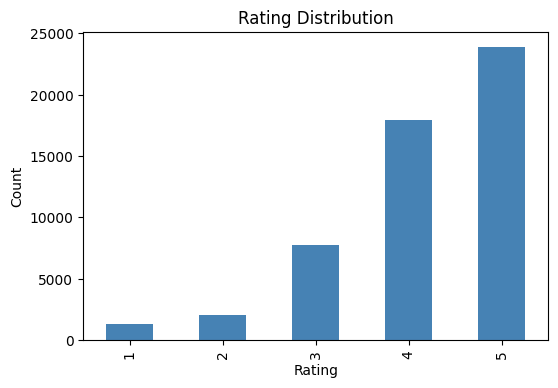

In [18]:
# Block 4.1: Rating Distribution
plt.figure(figsize=(6,4))
master_df_raw['Rating'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title('Rating Distribution')
plt.xlabel('Rating'); plt.ylabel('Count')
plt.show()

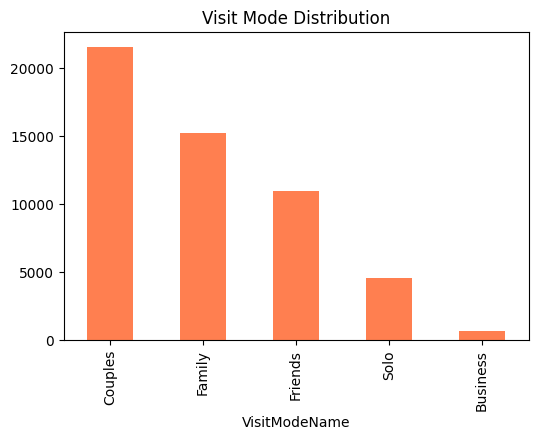

In [19]:
# Block 4.2: Visit Mode Distribution
plt.figure(figsize=(6,4))
master_df_raw['VisitModeName'].value_counts().plot(kind='bar', color='coral')
plt.title('Visit Mode Distribution')
plt.show()

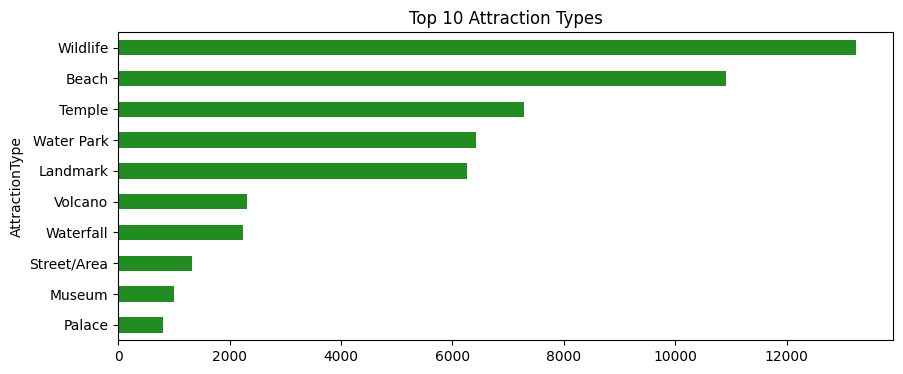

In [20]:
# Block 4.3: Popular Attraction Types
plt.figure(figsize=(10,4))
master_df_raw['AttractionType'].value_counts().head(10).plot(kind='barh', color='forestgreen')
plt.title('Top 10 Attraction Types')
plt.gca().invert_yaxis()
plt.show()

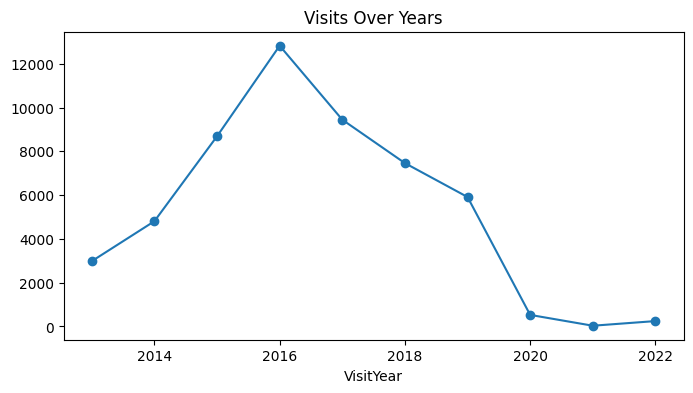

In [21]:
# Block 4.4: Visits Over Years
plt.figure(figsize=(8,4))
master_df_raw['VisitYear'].value_counts().sort_index().plot(marker='o')
plt.title('Visits Over Years')
plt.show()

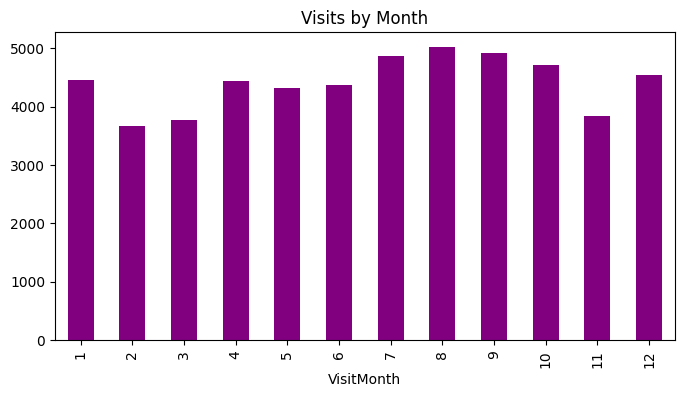

In [22]:
# Block 4.5: Visits by Month
plt.figure(figsize=(8,4))
master_df_raw['VisitMonth'].value_counts().sort_index().plot(kind='bar', color='purple')
plt.title('Visits by Month')
plt.show()

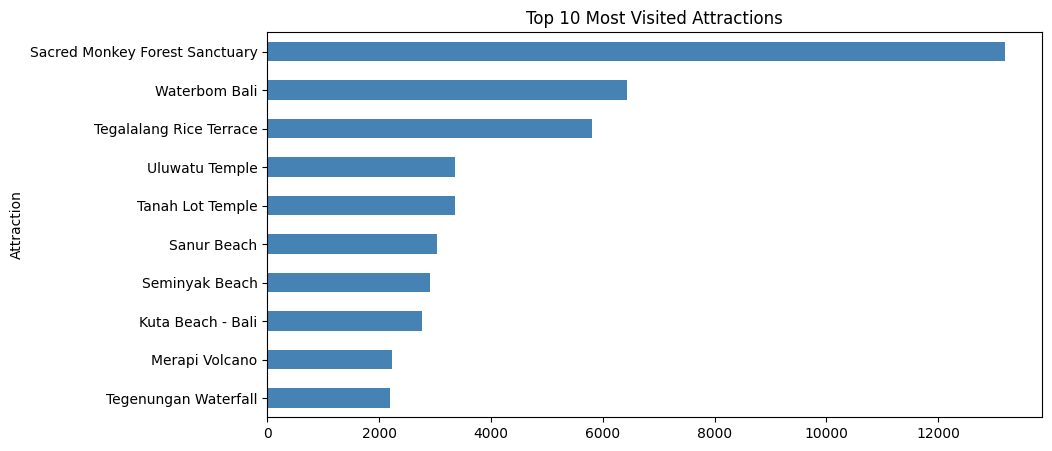

In [23]:
# Block 4.6: Top 10 Most Visited Attractions
top_attr = master_df_raw.groupby('Attraction').size().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
top_attr.plot(kind='barh', color='steelblue')
plt.title('Top 10 Most Visited Attractions')
plt.gca().invert_yaxis()
plt.show()

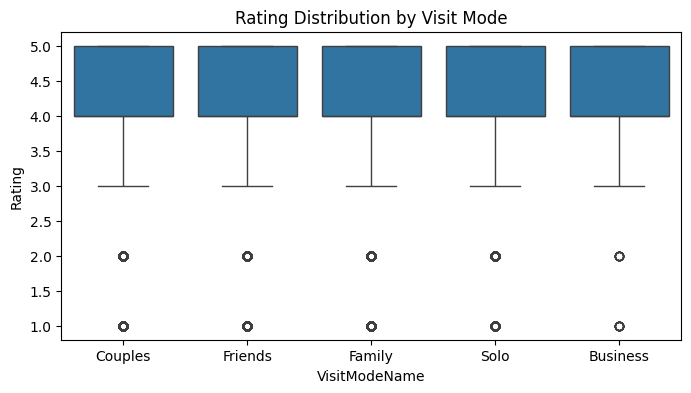

In [24]:
# Block 4.7: Rating by Visit Mode
plt.figure(figsize=(8,4))
sns.boxplot(data=master_df_raw, x='VisitModeName', y='Rating')
plt.title('Rating Distribution by Visit Mode')
plt.show()

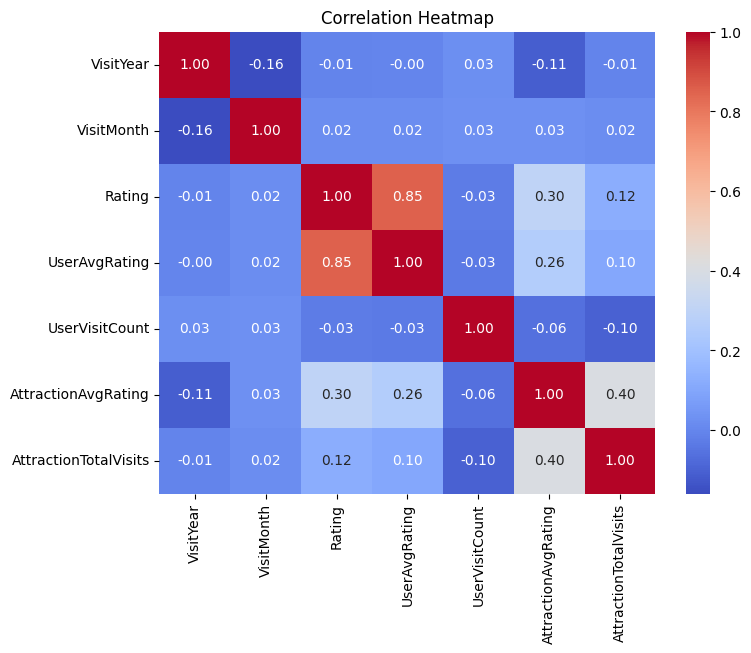

In [25]:
# Block 4.8: Correlation Heatmap
plt.figure(figsize=(8,6))
corr_cols = ['VisitYear','VisitMonth','Rating','UserAvgRating',
             'UserVisitCount','AttractionAvgRating','AttractionTotalVisits']
sns.heatmap(master_df_raw[corr_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

# PHASE 5: Regression — Predict Attraction Rating

In [26]:
# Block 5.1: Prepare Regression Data
reg_features = ['VisitYear', 'VisitMonth', 'VisitMode',
                'AttractionType_enc', 'VisitModeName_enc', 'Season_enc',
                'UserAvgRating', 'UserVisitCount', 'UserUniqueAttractions',
                'AttractionAvgRating', 'AttractionTotalVisits']

reg_df = master_df[reg_features + ['Rating']].dropna()

# ⚠️ Create a scaler specifically for regression features
reg_scaler = StandardScaler()
X_scaled = reg_scaler.fit_transform(reg_df[reg_features])
y = reg_df['Rating'].values

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)
print("Train:", X_train.shape, "Test:", X_test.shape)
print("y_train range:", y_train.min(), "-", y_train.max())

Train: (42344, 11) Test: (10586, 11)
y_train range: 1 - 5


In [27]:
# Block 5.2: Train Regression Models
reg_models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(max_depth=10, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=15,
                                            random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, max_depth=5,
                                                    random_state=42)
}

reg_results = {}
for name, model in reg_models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    reg_results[name] = {
        'MSE': mean_squared_error(y_test, preds),
        'RMSE': np.sqrt(mean_squared_error(y_test, preds)),
        'MAE': mean_absolute_error(y_test, preds),
        'R2': r2_score(y_test, preds)
    }
    print(f"{name}: RMSE={reg_results[name]['RMSE']:.4f}, R2={reg_results[name]['R2']:.4f}")

Linear Regression: RMSE=0.4972, R2=0.7375
Decision Tree: RMSE=0.5076, R2=0.7264
Random Forest: RMSE=0.5100, R2=0.7238
Gradient Boosting: RMSE=0.4857, R2=0.7495


,MSE,RMSE,MAE,R2
Gradient Boosting,0.235917,0.485713,0.258237,0.749509
Linear Regression,0.247247,0.497240,0.289983,0.737478
Decision Tree,0.257699,0.507641,0.258768,0.726380
Random Forest,0.260115,0.510015,0.262015,0.723816


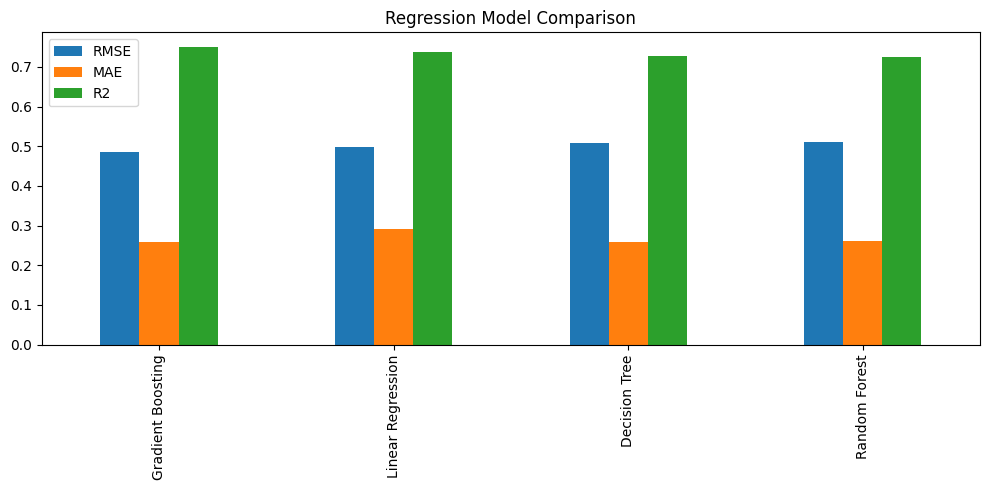

In [28]:
# Block 5.3: Regression Comparison
reg_compare = pd.DataFrame(reg_results).T.sort_values('RMSE')
display(reg_compare)

reg_compare[['RMSE','MAE','R2']].plot(kind='bar', figsize=(10,5))
plt.title('Regression Model Comparison')
plt.tight_layout(); plt.show()

Best Regression Model: Gradient Boosting


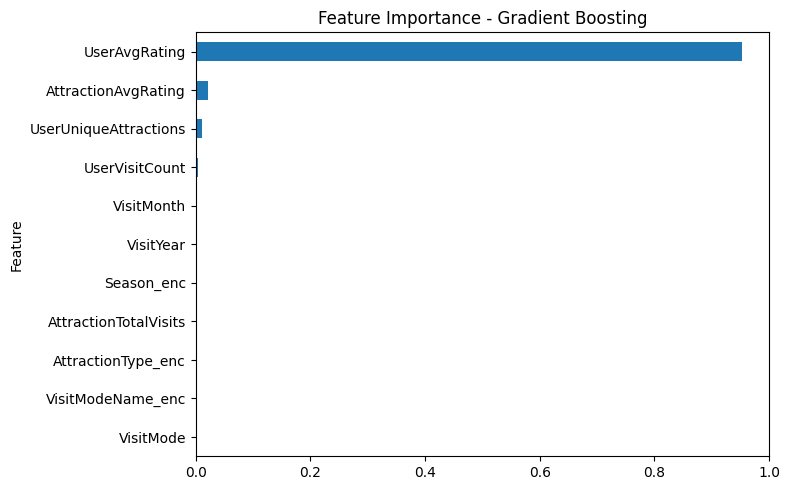

In [29]:
# Block 5.4: Feature Importance (Best Model)
best_reg_name = reg_compare.index[0]
best_reg_model = reg_models[best_reg_name]
print("Best Regression Model:", best_reg_name)

if hasattr(best_reg_model, 'feature_importances_'):
    imp = pd.DataFrame({'Feature': reg_features,
                        'Importance': best_reg_model.feature_importances_}
                      ).sort_values('Importance')
    imp.plot(kind='barh', x='Feature', y='Importance', figsize=(8,5), legend=False)
    plt.title(f'Feature Importance - {best_reg_name}')
    plt.tight_layout(); plt.show()

In [30]:
# Block 5.5: Verify Predictions Make Sense
sample_preds = best_reg_model.predict(X_test[:10])
print("Sample predictions:", np.round(sample_preds, 2))
print("Actual values:      ", y_test[:10])
print("Prediction range:", sample_preds.min(), "-", sample_preds.max())

Sample predictions: [4.34 3.45 3.23 4.01 4.   4.04 5.   3.99 4.99 5.04]
Actual values:       [5 5 3 4 5 4 5 4 5 5]
Prediction range: 3.2307501143390116 - 5.03820757560436


# PHASE 6: Classification — Predict Visit Mode

In [31]:
# Block 6.1: Prepare Classification Data
clf_features = ['VisitYear', 'VisitMonth', 'AttractionType_enc', 'Season_enc',
                'UserAvgRating', 'UserVisitCount', 'UserUniqueAttractions',
                'AttractionAvgRating', 'AttractionTotalVisits', 'Rating']

clf_df = master_df[clf_features + ['VisitMode_target']].dropna()

# Use separate scaler for classification too
clf_scaler = StandardScaler()
X_clf_scaled = clf_scaler.fit_transform(clf_df[clf_features])
y_clf = clf_df['VisitMode_target'].values

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf_scaled, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)
print("Train:", X_train_c.shape, "Test:", X_test_c.shape)

Train: (42344, 10) Test: (10586, 10)


In [37]:
# Block 6.2: Train Classification Models
clf_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=10, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=15,
                                             random_state=42, n_jobs=-1),
    'LightGBM': lgb.LGBMClassifier(n_estimators=100, max_depth=5,
                                    random_state=42, verbose=-1)
}

clf_results = {}
for name, model in clf_models.items():
    model.fit(X_train_c, y_train_c)
    preds = model.predict(X_test_c)
    clf_results[name] = {
        'Accuracy': accuracy_score(y_test_c, preds),
        'Precision': precision_score(y_test_c, preds, average='weighted'),
        'Recall': recall_score(y_test_c, preds, average='weighted'),
        'F1': f1_score(y_test_c, preds, average='weighted')
    }
    print(f"{name}: Accuracy={clf_results[name]['Accuracy']:.4f}, F1={clf_results[name]['F1']:.4f}")

Logistic Regression: Accuracy=0.4515, F1=0.3644
Decision Tree: Accuracy=0.4640, F1=0.3978
Random Forest: Accuracy=0.4895, F1=0.4415
LightGBM: Accuracy=0.4821, F1=0.4229


,Accuracy,Precision,Recall,F1
Random Forest,0.489514,0.503891,0.489514,0.441545
LightGBM,0.482052,0.498862,0.482052,0.422904
Decision Tree,0.464009,0.454496,0.464009,0.397774
Logistic Regression,0.451540,0.405883,0.451540,0.364403


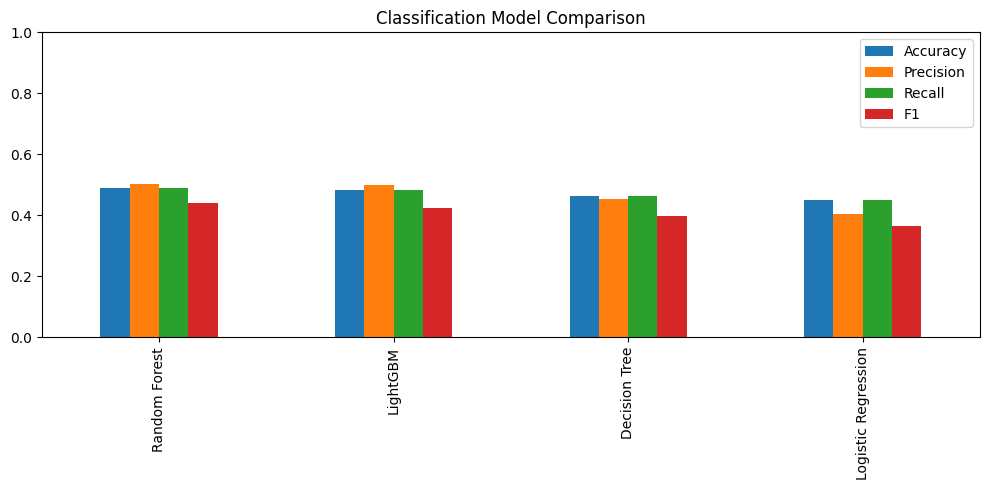

In [38]:
# Block 6.3: Classification Comparison
clf_compare = pd.DataFrame(clf_results).T.sort_values('F1', ascending=False)
display(clf_compare)

clf_compare.plot(kind='bar', figsize=(10,5))
plt.title('Classification Model Comparison')
plt.ylim(0,1); plt.tight_layout(); plt.show()

In [39]:
# Block 6.4: Detailed Report for Best Model
best_clf_name = clf_compare.index[0]
best_clf_model = clf_models[best_clf_name]
print("Best Classification Model:", best_clf_name)

y_pred = best_clf_model.predict(X_test_c)
print("\nClassification Report:")
print(classification_report(y_test_c, y_pred, target_names=le_target.classes_))

Best Classification Model: Random Forest

Classification Report:
              precision    recall  f1-score   support

    Business       0.75      0.07      0.13       125
     Couples       0.48      0.83      0.61      4324
      Family       0.54      0.37      0.44      3043
     Friends       0.44      0.18      0.25      2189
        Solo       0.62      0.09      0.16       905

    accuracy                           0.49     10586
   macro avg       0.57      0.31      0.32     10586
weighted avg       0.50      0.49      0.44     10586



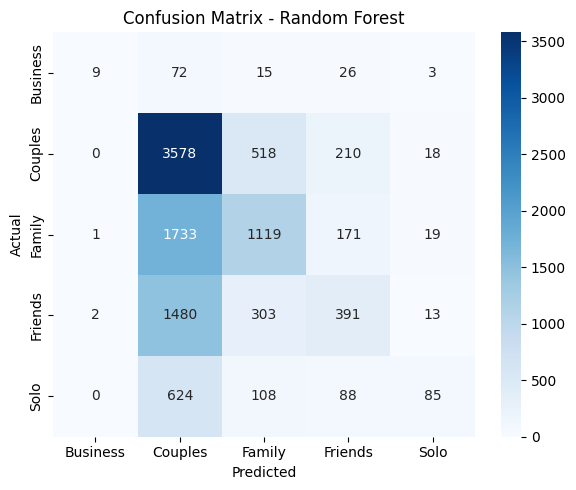

In [40]:
# Block 6.5: Confusion Matrix
cm = confusion_matrix(y_test_c, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_target.classes_, yticklabels=le_target.classes_)
plt.title(f'Confusion Matrix - {best_clf_name}')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout(); plt.show()

# PHASE 7: Recommendation System


In [71]:
# ============================================================
# Block 7.1: Build User-Item Matrix
# ============================================================
user_item_matrix = master_df_raw.pivot_table(
    index='UserId',
    columns='AttractionId',
    values='Rating',
    fill_value=0
)

n_users, n_items = user_item_matrix.shape
print(f"User-Item Matrix Shape: {user_item_matrix.shape}")
print(f"  Users:       {n_users}")
print(f"  Attractions: {n_items}")
print(f"  Sparsity:    {(user_item_matrix == 0).sum().sum() / user_item_matrix.size:.4f}")

User-Item Matrix Shape: (33530, 30)
  Users:       33530
  Attractions: 30
  Sparsity:    0.9550


In [72]:
# ============================================================
# Block 7.2: Safe SVD Wrapper (handles small matrices)
# ============================================================
from sklearn.decomposition import TruncatedSVD

def safe_svd(matrix, desired_components=50, random_state=42):
    """
    Fit TruncatedSVD with automatically clamped n_components.
    Returns (user_factors, item_factors, svd_model, actual_n_components).
    """
    n_rows, n_cols = matrix.shape
    max_allowed = min(n_rows, n_cols) - 1

    if max_allowed < 2:
        raise ValueError(
            f"Matrix too small for SVD: shape={matrix.shape}. "
            f"Need min(rows, cols) >= 3."
        )

    n_components = min(desired_components, max_allowed)
    print(f"safe_svd: shape={matrix.shape} → using n_components={n_components}")

    svd = TruncatedSVD(n_components=n_components, random_state=random_state)
    user_factors = svd.fit_transform(matrix)
    item_factors = svd.components_.T

    print(f"Explained variance: {svd.explained_variance_ratio_.sum():.4f}")
    return user_factors, item_factors, svd, n_components


# ---- Fit SVD safely ----
user_factors, item_factors, svd_model, n_comp_used = safe_svd(
    user_item_matrix, desired_components=50
)

print("\nUser factors:", user_factors.shape)
print("Item factors:", item_factors.shape)
print("n_components used:", n_comp_used)

safe_svd: shape=(33530, 30) → using n_components=29
Explained variance: 0.9993

User factors: (33530, 29)
Item factors: (30, 29)
n_components used: 29


In [73]:
# ============================================================
# Block 7.3: Content-Based Filtering
# ============================================================
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

item_content = item_df.copy()
item_content['content'] = (
    item_content['Attraction'].fillna('') + ' ' +
    item_content['AttractionType'].fillna('') + ' ' +
    item_content['AttractionAddress'].fillna('')
)

tfidf = TfidfVectorizer(stop_words='english', max_features=500)
tfidf_matrix = tfidf.fit_transform(item_content['content'])
content_sim = cosine_similarity(tfidf_matrix)
attraction_to_idx = {aid: i for i, aid in enumerate(item_content['AttractionId'])}

print("Content similarity matrix:", content_sim.shape)
print("Attractions indexed:", len(attraction_to_idx))

Content similarity matrix: (30, 30)
Attractions indexed: 30


In [74]:
# ============================================================
# Block 7.4: Popularity Scores (Normalized 0-1)
# ============================================================
pop = master_df_raw.groupby('AttractionId').agg(
    AvgRating=('Rating', 'mean'),
    Visits=('TransactionId', 'count')
).reset_index()

pop['NormRating'] = pop['AvgRating'] / 5.0

# Avoid division by zero if all attractions have same visit count
visits_min = pop['Visits'].min()
visits_max = pop['Visits'].max()
if visits_max > visits_min:
    pop['NormVisits'] = (pop['Visits'] - visits_min) / (visits_max - visits_min)
else:
    pop['NormVisits'] = 0.5

pop['Popularity'] = 0.5 * pop['NormRating'] + 0.5 * pop['NormVisits']
popularity_scores = dict(zip(pop['AttractionId'], pop['Popularity']))

print(f"Popularity computed for {len(popularity_scores)} attractions")
print(f"Popularity range: {min(popularity_scores.values()):.4f} – {max(popularity_scores.values()):.4f}")

Popularity computed for 30 attractions
Popularity range: 0.3592 – 0.9267


In [75]:
# ============================================================
# Block 7.5: Hybrid Recommender Class
# ============================================================
class HybridRecommender:
    """
    Hybrid Recommender combining:
      - Collaborative Filtering (SVD)
      - Content-Based Filtering
      - Popularity-based fallback
    All sub-scores are normalized to [0, 1] before blending.
    """

    def __init__(self, user_item_matrix, user_factors, item_factors,
                 content_sim, item_content, attraction_to_idx,
                 popularity_scores, cf_w=0.5, cb_w=0.3, pop_w=0.2):
        self.user_item_matrix = user_item_matrix
        self.user_factors = user_factors
        self.item_factors = item_factors
        self.content_sim = content_sim
        self.item_content = item_content
        self.attraction_to_idx = attraction_to_idx
        self.popularity_scores = popularity_scores
        self.cf_w, self.cb_w, self.pop_w = cf_w, cb_w, pop_w

    def get_history(self, user_id):
        """Attractions already rated by the user."""
        if user_id not in self.user_item_matrix.index:
            return set()
        r = self.user_item_matrix.loc[user_id]
        return set(r[r > 0].index)

    def cf_scores(self, user_id):
        """Raw SVD-based predicted ratings."""
        if user_id not in self.user_item_matrix.index:
            return {}
        idx = list(self.user_item_matrix.index).index(user_id)
        pred = self.user_factors[idx] @ self.item_factors.T
        return dict(zip(self.user_item_matrix.columns, pred))

    def cb_scores(self, user_id):
        """Content-based similarity to liked attractions."""
        history = self.get_history(user_id)
        if not history:
            return {}
        r = self.user_item_matrix.loc[user_id]
        liked = r[r >= 4].index.tolist() or list(history)[:5]

        scores = {}
        for aid in self.item_content['AttractionId']:
            if aid not in self.attraction_to_idx:
                continue
            ti = self.attraction_to_idx[aid]
            sims = [
                self.content_sim[ti][self.attraction_to_idx[l]]
                for l in liked if l in self.attraction_to_idx
            ]
            scores[aid] = float(np.mean(sims)) if sims else 0.0
        return scores

    @staticmethod
    def _normalize(d):
        """Min-max normalize a dict of scores to [0, 1]."""
        if not d:
            return {}
        vals = list(d.values())
        lo, hi = min(vals), max(vals)
        if hi > lo:
            return {k: (v - lo) / (hi - lo) for k, v in d.items()}
        return {k: 0.5 for k in d}

    def recommend(self, user_id, n=10):
        """Return top-n recommendations."""
        history = self.get_history(user_id)

        cf = self._normalize(self.cf_scores(user_id))
        cb = self._normalize(self.cb_scores(user_id))

        recs = []
        for aid in self.item_content['AttractionId']:
            if aid in history:
                continue

            cf_s = cf.get(aid, 0.0)
            cb_s = cb.get(aid, 0.0)
            pop_s = self.popularity_scores.get(aid, 0.0)

            # Cold-start: no history → use popularity only
            if not history:
                score = pop_s
            else:
                score = (self.cf_w * cf_s +
                         self.cb_w * cb_s +
                         self.pop_w * pop_s)

            recs.append({
                'AttractionId': aid,
                'CF_Score': cf_s,
                'CB_Score': cb_s,
                'Pop_Score': pop_s,
                'Score': score
            })

        rec_df = (pd.DataFrame(recs)
                    .sort_values('Score', ascending=False)
                    .head(n))

        rec_df = rec_df.merge(
            item_content[['AttractionId', 'Attraction',
                          'AttractionType', 'AttractionAddress']],
            on='AttractionId', how='left'
        )
        return rec_df


# ---- Instantiate ----
recommender = HybridRecommender(
    user_item_matrix=user_item_matrix,
    user_factors=user_factors,
    item_factors=item_factors,
    content_sim=content_sim,
    item_content=item_content,
    attraction_to_idx=attraction_to_idx,
    popularity_scores=popularity_scores,
    cf_w=0.5, cb_w=0.3, pop_w=0.2
)
print("Hybrid recommender ready.")

Hybrid recommender ready.


In [76]:
# ============================================================
# Block 7.6: Test Recommendations
# ============================================================
sample_user = user_item_matrix.index[0]
print(f"Sample user: {sample_user}")
print(f"User history size: {len(recommender.get_history(sample_user))}")

recs = recommender.recommend(sample_user, n=10)
print(f"\nTop 10 recommendations for user {sample_user}:")
display(recs[['Attraction', 'AttractionType',
              'CF_Score', 'CB_Score', 'Pop_Score', 'Score']])

Sample user: 14
User history size: 2

Top 10 recommendations for user 14:


,Attraction,AttractionType,CF_Score,CB_Score,Pop_Score,Score
0,Waterbom Bali,Water Park,0.000179,0.075392,0.707675,0.164242
1,Tegenungan Waterfall,Waterfall,0.000179,0.186206,0.471624,0.150276
2,Uluwatu Temple,Temple,0.000179,0.122910,0.548403,0.146643
3,Water Castle (Tamansari),Landmark,0.000180,0.168914,0.394599,0.129684
4,Nusa Dua Beach,Beach,0.000179,0.074989,0.506382,0.123863
5,Sempu Island,Wildlife,0.000181,0.124053,0.421704,0.121647
6,Tanah Lot Temple,Temple,0.000179,0.033066,0.545677,0.119145
7,Malang City Square,Landmark,0.000183,0.151695,0.359179,0.117436
8,Ullen Sentalu Museum,Museum,0.000180,0.066543,0.461731,0.112399
9,Bromo Tengger Semeru National Park,National Park,0.000180,0.030435,0.474557,0.104132


In [77]:
# ============================================================
# Block 7.7: Proper RMSE Evaluation (Holdout, no leakage)
# ============================================================
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error


def evaluate_rmse_holdout(master_df_raw, desired_components=50,
                          test_size=0.2, random_state=42):
    """
    Proper holdout evaluation:
      1. Split raw ratings into train / test (80/20).
      2. Fit SVD on TRAIN ONLY.
      3. Predict on TEST ratings.
      4. Return RMSE, MAE, and count of evaluated ratings.
    """
    ratings = master_df_raw[['UserId', 'AttractionId', 'Rating']].dropna()
    train_r, test_r = train_test_split(
        ratings, test_size=test_size, random_state=random_state
    )

    # Build train matrix
    train_matrix = train_r.pivot_table(
        index='UserId', columns='AttractionId',
        values='Rating', fill_value=0
    )
    print(f"Train matrix shape: {train_matrix.shape}")

    # Safe SVD on train only
    try:
        uf, itf, _, n_used = safe_svd(train_matrix, desired_components)
    except ValueError as e:
        print("SVD failed:", e)
        return None, None, 0

    users = list(train_matrix.index)
    items = list(train_matrix.columns)
    user_pos = {u: i for i, u in enumerate(users)}
    item_pos = {a: i for i, a in enumerate(items)}

    preds, actuals = [], []
    for _, row in test_r.iterrows():
        u = int(row['UserId'])
        a = int(row['AttractionId'])
        actual = float(row['Rating'])

        if u in user_pos and a in item_pos:
            pred = float(np.clip(uf[user_pos[u]] @ itf[item_pos[a]], 1, 5))
            preds.append(pred)
            actuals.append(actual)

    if not preds:
        print("No matching test items — cannot evaluate.")
        return None, None, 0

    rmse = np.sqrt(mean_squared_error(actuals, preds))
    mae = mean_absolute_error(actuals, preds)

    print(f"\nEvaluated on {len(preds):,} test ratings")
    return rmse, mae, len(preds)


rmse_rec, mae_rec, n_eval = evaluate_rmse_holdout(
    master_df_raw, desired_components=50
)

if rmse_rec is not None:
    print(f"\n✅ Recommender RMSE : {rmse_rec:.4f}")
    print(f"✅ Recommender MAE  : {mae_rec:.4f}")
    print(f"✅ Test ratings     : {n_eval:,}")
else:
    print("⚠️ Could not evaluate — dataset too small.")

Train matrix shape: (28700, 30)
safe_svd: shape=(28700, 30) → using n_components=29
Explained variance: 0.9992

Evaluated on 5,434 test ratings

✅ Recommender RMSE : 2.5795
✅ Recommender MAE  : 2.0553
✅ Test ratings     : 5,434


# PHASE 8: Save Artifacts

In [78]:
# ============================================================
# Block 8.1: Save all models + data needed by the app
# ============================================================
artifacts = {
    # ---------- Regression ----------
    'regression_model': best_reg_model,
    'regression_features': reg_features,
    'reg_scaler': reg_scaler,
    'best_reg_name': best_reg_name,

    # ---------- Classification ----------
    'classification_model': best_clf_model,
    'classification_features': clf_features,
    'clf_scaler': clf_scaler,
    'best_clf_name': best_clf_name,

    # ---------- Recommendation ----------
    'user_item_matrix': user_item_matrix,
    'user_factors': user_factors,
    'item_factors': item_factors,
    'svd_n_components': n_comp_used,         # ✅ new
    'content_sim': content_sim,
    'item_content': item_content,
    'attraction_to_idx': attraction_to_idx,
    'popularity_scores': popularity_scores,

    # ---------- Encoders ----------
    'le_target': le_target,
    'le_type': le_type,
    'le_mode': le_mode,
    'le_season': le_season,

    # ---------- Extra ----------
    'user_features': user_features,
    'attraction_features': attraction_features
}

joblib.dump(artifacts, 'tourism_models.pkl')
print("✅ Models saved to tourism_models.pkl")

# ---- Sanity check ----
check = joblib.load('tourism_models.pkl')
required = [
    'regression_model', 'reg_scaler', 'classification_model', 'clf_scaler',
    'user_item_matrix', 'user_factors', 'item_factors', 'svd_n_components',
    'popularity_scores', 'le_target', 'le_type', 'le_mode', 'le_season'
]
missing = [k for k in required if k not in check]
print("Missing keys:", missing if missing else "None ✅")
print("Regressor:", type(check['regression_model']).__name__)
print("SVD components used:", check['svd_n_components'])

✅ Models saved to tourism_models.pkl
Missing keys: None ✅
Regressor: GradientBoostingRegressor
SVD components used: 29


In [79]:
# ============================================================
# Block 8.2: Save cleaned datasets
# ============================================================
master_df_raw.to_csv('master_dataset_clean.csv', index=False)
user_features.to_csv('user_features.csv', index=False)
attraction_features.to_csv('attraction_features.csv', index=False)
print("✅ Datasets saved.")

✅ Datasets saved.
